In [1]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True  # Disable the interactive preview widget.

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, RadioMaterial, Camera
from sionna.rt.utils import r_hat

In [ ]:
import importlib
import sys

def check_tensorflow():
    if importlib.util.find_spec("tensorflow") is None:
        print("[TensorFlow] not installed")
        return
    import tensorflow as tf
    print(f"[TensorFlow] version: {tf.__version__}")
    print(f"[TensorFlow] CUDA support: {tf.test.is_built_with_cuda()}")
    print(f"[TensorFlow] available GPUs: {tf.config.list_physical_devices('GPU')}")

def check_pytorch():
    if importlib.util.find_spec("torch") is None:
        print("\n[PyTorch] not installed")
        return
    import torch
    print(f"\n[PyTorch] version: {torch.__version__}")
    print(f"[PyTorch] CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"[PyTorch] GPU count: {torch.cuda.device_count()}")
        for i in range(torch.cuda.device_count()):
            print(f"[PyTorch] GPU {i} name: {torch.cuda.get_device_name(i)}")

def check_sionna():
    if importlib.util.find_spec("sionna") is None:
        print("\n[Sionna] not installed")
        return
    import sionna
    print(f"\n[Sionna] version: {sionna.__version__}")
    try:
        # Check whether Sionna can access TensorFlow GPUs.
        import tensorflow as tf
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            print(f"[Sionna] available GPU count: {len(gpus)}")
        else:
            print("[Sionna] no GPU detected through TensorFlow")
    except Exception as e:
        print(f"[Sionna] GPU check failed: {e}")

if __name__ == "__main__":
    print(f"Python version: {sys.version}\n")
    check_tensorflow()
    check_pytorch()
    check_sionna()


Python version: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]



2026-05-17 09:42:07.624224: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 09:42:11.791538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779036132.875796  663469 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779036133.158651  663469 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779036135.761895  663469 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

[TensorFlow] version: 2.19.0
[TensorFlow] CUDA support: True
[TensorFlow] available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

[PyTorch] version: 2.5.1+cu121
[PyTorch] CUDA available: True
[PyTorch] GPU count: 1
[PyTorch] GPU 0 name: NVIDIA GeForce RTX 3060 Ti

[Sionna] version: 1.1.0
[Sionna] available GPU count: 1


In [3]:
import tensorflow as tf
print("GPU devices:", tf.config.list_physical_devices('GPU'))

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os
gpu_num = 0 # Use "" to use the CPU
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import shapely
from utils import *
from pyproj import Transformer

import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Load integrated scene
# sionna.rt.scene.munich
from pathlib import Path

def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "assets" / "raytrack_scene" / "scene.xml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the RayLoc project root.")

PROJECT_ROOT = find_project_root()
GENERATED_DIR = PROJECT_ROOT / "generated"
GENERATED_DIR.mkdir(parents=True, exist_ok=True)
SCENE_PATH = PROJECT_ROOT / "assets" / "raytrack_scene" / "scene.xml"

scene = load_scene(str(SCENE_PATH))
# scene.preview()

2026-05-17 09:47:12 WARN wrk6 [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).

In [7]:
#convert lat lon to coordinate
def sionna_coord(target_latlon):

    #bound
    bl = (-122.312299126737, 47.65074792715546)
    ur = (-122.30187970485449, 47.65690207846001)
    box = [bl, (bl[0], ur[1]), ur, (ur[0], bl[1])]

    target_coord_flipped = (target_latlon[1], target_latlon[0])

    #find epsg code for projection
    EPSG_code = get_utm_epsg_code_from_gps(bl[0], bl[1])
    to_utm = Transformer.from_crs("EPSG:4326", EPSG_code, always_xy=True)

    target_utm = to_utm.transform(target_coord_flipped[0], target_coord_flipped[1])

    #find center
    ground_utm = [to_utm.transform(lon, lat) for lon, lat in box]
    ground_polygon_utm = shapely.geometry.Polygon(ground_utm)
    ground_envelop = ground_polygon_utm.envelope
    center_x = ground_envelop.centroid.x
    center_y = ground_envelop.centroid.y

    #relative coord
    relative_coord = (target_utm[0] - center_x, target_utm[1] - center_y)

    return relative_coord

def sionna_coord_batch(latlon_array):
    """
    latlon_array: [N,2] -> [[lat, lon], ...]
    return: [N,2] -> [[x, y], ...]
    """

    latlon_array = np.asarray(latlon_array)
    assert latlon_array.shape[1] == 2, "Input must be Nx2 [lat, lon]"

    # =========================
    # 1. bounding box
    # =========================
    bl = (-122.312299126737, 47.65074792715546)
    ur = (-122.30187970485449, 47.65690207846001)
    box = [bl, (bl[0], ur[1]), ur, (ur[0], bl[1])]

    # =========================
    # 2. projection (computed once)
    # =========================
    EPSG_code = get_utm_epsg_code_from_gps(bl[0], bl[1])
    to_utm = Transformer.from_crs("EPSG:4326", EPSG_code, always_xy=True)

    # =========================
    # 3. compute center
    # =========================
    ground_utm = np.array([to_utm.transform(lon, lat) for lon, lat in box])
    ground_polygon_utm = shapely.geometry.Polygon(ground_utm)
    center_x = ground_polygon_utm.envelope.centroid.x
    center_y = ground_polygon_utm.envelope.centroid.y

    # =========================
    # 4. lat/lon -> utm (vectorized)
    # =========================
    lats = latlon_array[:, 0]
    lons = latlon_array[:, 1]

    # pyproj supports vectorized transforms.
    utm_x, utm_y = to_utm.transform(lons, lats)

    utm_x = np.array(utm_x)
    utm_y = np.array(utm_y)

    # =========================
    # 5. relative coord
    # =========================
    rel_x = utm_x - center_x
    rel_y = utm_y - center_y

    return np.stack([rel_x, rel_y], axis=1)

In [8]:
#calibration test
target = np.array([47.655107665483904, -122.3086761875066])

relative_coord = sionna_coord(target)

# set tx
scene.remove("tx")

tx = Transmitter(name="tx",
                 position=[relative_coord[0], relative_coord[1], 0],
                 orientation=[0,0,0])

scene.add(tx)

#scene.preview()

In [ ]:
#configure building material
#def material itu concrete
# Sionna radio-material reference: https://nvlabs.github.io/sionna/api/rt.html#radio-materials
def medium_dry_ground_callback(f_hz):
   a = 15
   b = -0.1
   c = 0.035
   d = 1.63

   relative_permittivity = a * (f_hz*10e-9)**b
   conductivity = c * (f_hz*10e-9)**d
   return (relative_permittivity, conductivity)

def concrete_callback(f_hz):
   a = 5.24 #5.24
   b = 0
   c = 0.0462
   d = 0.7822

   relative_permittivity = a * (f_hz*10e-9)**b
   conductivity = c * (f_hz*10e-9)**d
   return (relative_permittivity, conductivity)

def plasterboard_callback(f_hz):
   a = 2.73 
   b = 0
   c = 0.0085
   d = 0.9395

   relative_permittivity = a * (f_hz*10e-9)**b
   conductivity = c * (f_hz*10e-9)**d
   return (relative_permittivity, conductivity)

def wood_callback(f_hz):
   a = 1.99 
   b = 0
   c = 0.0047
   d = 1.0718

   relative_permittivity = a * (f_hz*10e-9)**b
   conductivity = c * (f_hz*10e-9)**d
   return (relative_permittivity, conductivity)

def brick_callback(f_hz):
   a = 3.91 
   b = 0
   c = 0.0238
   d = 0.16

   relative_permittivity = a * (f_hz*10e-9)**b
   conductivity = c * (f_hz*10e-9)**d
   return (relative_permittivity, conductivity)

def manual_callback(f_hz):
   a = 1.48 
   b = 0
   c = 0.0011
   d = 1.0750

   relative_permittivity = a * (f_hz*10e-9)**b
   conductivity = c * (f_hz*10e-9)**d
   return (relative_permittivity, conductivity)

concrete_all_frequency = RadioMaterial("concrete_all_frequency",
                                frequency_update_callback=concrete_callback)
scene.add(concrete_all_frequency)

ground_all_frequency = RadioMaterial("ground_all_frequency",
                                frequency_update_callback=medium_dry_ground_callback)
scene.add(ground_all_frequency)

plasterboard_all_frequency = RadioMaterial("plasterboard_all_frequency",
                                frequency_update_callback=plasterboard_callback)
scene.add(plasterboard_all_frequency)

wood_all_frequency = RadioMaterial("wood_all_frequency",
                                frequency_update_callback=wood_callback)
scene.add(wood_all_frequency)

brick_all_frequency = RadioMaterial("brick_all_frequency",
                                frequency_update_callback=brick_callback)
scene.add(brick_all_frequency)

manual_all_frequency = RadioMaterial("manual_all_frequency",
                                frequency_update_callback=manual_callback)
scene.add(manual_all_frequency)

In [10]:
print(list(scene.objects))

['no-name-1', 'ground']


In [11]:
for i in range(len(list(scene.objects.keys()))):
    obj_name = list(scene.objects.keys())[i]
    obj = scene.get(obj_name)

    if (obj_name != "ground"):
        obj.radio_material = concrete_all_frequency
    else:
        obj.radio_material = ground_all_frequency

    obj.radio_material.scattering_coefficient = 0.5

scene.remove('itu_concrete')
scene.remove('itu_medium_dry_ground')

#frequency, tx rx array, and material configuration
scene.frequency = 915e6 # in Hz; implicitly updates RadioMaterials
# scene.frequency = 2e9

scene.synthetic_array = True # If set to False, ray tracing will be done per antenna element (slower for large arrays)

#print(scene.objects)
# obj = scene.get(list(scene.objects.keys())[0])
# print(list(scene.objects.keys()))
# obj.radio_material = concrete_all_frequency
# obj.radio_material.scattering_coefficient = 0.5

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="V")

scene.rx_array = scene.tx_array

In [12]:
# set tx
lab1_gps = (47.65361769298625, -122.30694886733762) #13 
lab1_coord = sionna_coord(lab1_gps)

window_gps = (47.653750, -122.306494) #10.6
window_coord = sionna_coord(window_gps)

scene.remove("tx")

tx = Transmitter(name="tx",
                 position=[lab1_coord[0], lab1_coord[1], 13],
                 orientation=[0,0,0])

scene.add(tx)
# scene.preview()

In [138]:
#coverage map
rm_solver = RadioMapSolver()

cm = rm_solver(scene = scene,
                max_depth=5, #less max_depth to see more contrast
                refraction=True, # Disable to see the effects of diffraction
                cell_size=(1., 1.), # Grid size of coverage map cells in m
                samples_per_tx =int(1e8),
                specular_reflection = True,
                diffuse_reflection = True)

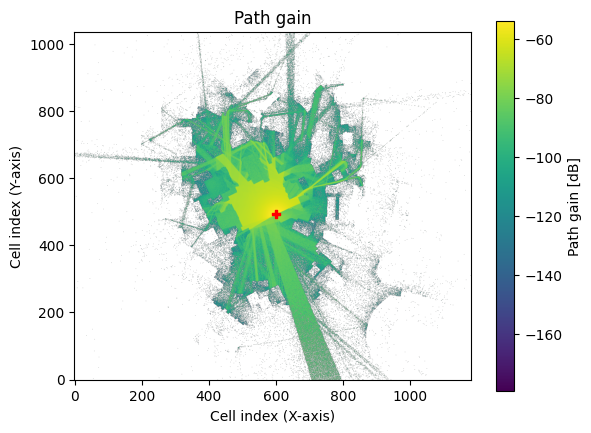

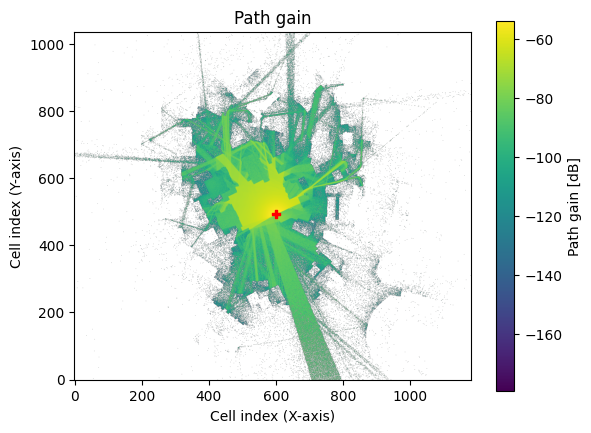

In [139]:
cm.show()

/tmp/ipykernel_9226/3209426617.py:64: RuntimeWarning: divide by zero encountered in log10
  rss_db      = 10 * np.log10(rss)


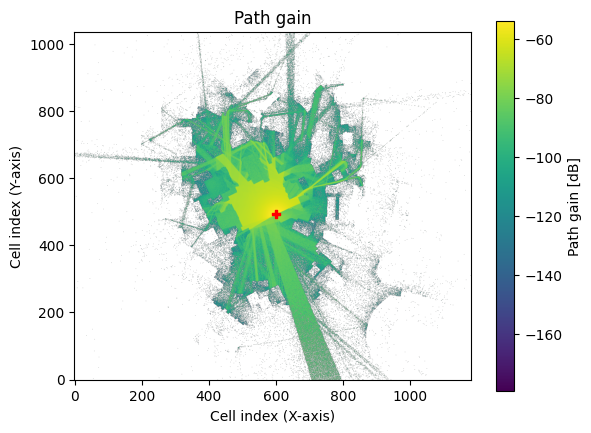

In [150]:
def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if hasattr(x, "numpy"):
        return x.numpy()
    try:
        return np.array(x)
    except Exception:
        return np.asarray(x)

name = "concrete_scene"
for i in range(len(list(scene.objects.keys()))):
    obj_name = list(scene.objects.keys())[i]
    obj = scene.get(obj_name)

    if (obj_name != "ground"):
        obj.radio_material = concrete_all_frequency
    else:
        obj.radio_material = ground_all_frequency

    obj.radio_material.scattering_coefficient = 0.5

scene.remove('itu_concrete')
scene.remove('itu_medium_dry_ground')

#frequency, tx rx array, and material configuration
scene.frequency = 915e6 # in Hz; implicitly updates RadioMaterials
# scene.frequency = 2e9

scene.synthetic_array = True # If set to False, ray tracing will be done per antenna element (slower for large arrays)

#print(scene.objects)
# obj = scene.get(list(scene.objects.keys())[0])
# print(list(scene.objects.keys()))
# obj.radio_material = concrete_all_frequency
# obj.radio_material.scattering_coefficient = 0.5

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="V")

scene.rx_array = scene.tx_array

#coverage map
rm_solver = RadioMapSolver()

cm = rm_solver(scene = scene,
                max_depth=5, #less max_depth to see more contrast
                refraction=True, # Disable to see the effects of diffraction
                cell_size=(1., 1.), # Grid size of coverage map cells in m
                samples_per_tx =int(1e8),
                specular_reflection = True,
                diffuse_reflection = True)

cm.show()

rss = np.squeeze(to_numpy(cm.rss))
pg  = np.squeeze(to_numpy(cm.path_gain))
cc  = to_numpy(cm.cell_centers)

rss_db      = 10 * np.log10(rss)

save_dir = GENERATED_DIR / "material_sensitivity"
os.makedirs(save_dir, exist_ok=True)
# np.savez_compressed(
#     os.path.join(save_dir, f"{name}.npz"),
#     rss=rss,
#     rss_db=rss_db,
#     path_gain=pg,
#     cell_centers=cc,
# )